In [51]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer


In [25]:
df = pd.read_json("../data/supervise_myth_clusters.json", lines=True)
df_tropes = pd.read_json("../data/binary_myth_tropes.json", orient="records", lines=True)
print(df.columns)

Index(['id', 'text', 'type', 'source', 'imdb_title', 'imdb_year',
       'imdb_genres', 'inferred_media_type', 'combined_text',
       'has_semantic_match', 'has_lexical_match',
       'has_sentence_myth_trope_hit', 'max_trope_similarity', 'myth_hit_count',
       'myth_theme', 'cluster', 'has_myth_hit', 'has_myth_trope_hit',
       'agglo_cluster'],
      dtype='object')


In [13]:
X = df_tropes.drop(columns=['cluster'])
y = df['cluster']

In [14]:
ovr_rf = OneVsRestClassifier(
    RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
)

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores using macro F1
scores = cross_val_score(ovr_rf, X, y, cv=cv, scoring='f1_macro')
print(f"Cross-validated Macro F1 Score: {np.mean(scores):.4f} ± {np.std(scores):.4f}")


Cross-validated Macro F1 Score: 0.9940 ± 0.0024


In [16]:
ovr_rf.fit(X, y)

,estimator,RandomForestC...ndom_state=42)
,n_jobs,None
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None


In [17]:
y_pred = ovr_rf.predict(X)
print(classification_report(y, y_pred))
print(confusion_matrix(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       609
           1       1.00      0.99      1.00       794
           2       0.99      1.00      0.99       528
           3       1.00      1.00      1.00       344

    accuracy                           1.00      2275
   macro avg       1.00      1.00      1.00      2275
weighted avg       1.00      1.00      1.00      2275

[[609   0   0   0]
 [  0 788   6   0]
 [  0   0 528   0]
 [  0   0   0 344]]


In [18]:
feature_names = X.columns

# For each classifier (one per cluster)
for idx, estimator in enumerate(ovr_rf.estimators_):
    importances = estimator.feature_importances_
    top_indices = np.argsort(importances)[::-1][:10]
    print(f"\nTop features for Cluster {idx}:")
    for i in top_indices:
        print(f"{feature_names[i]}: {importances[i]:.4f}")


Top features for Cluster 0:
Reincarnation: 0.4211
BigBad: 0.2633
TheTrickster: 0.0582
Animal_Beast: 0.0561
DragonsAreDivine: 0.0302
Trickster God: 0.0164
Satan: 0.0131
WarGod: 0.0120
WhiteMage: 0.0111
TheChosenOne: 0.0109

Top features for Cluster 1:
TheTrickster: 0.3249
Animal_Beast: 0.3051
Reincarnation: 0.1423
BigBad: 0.0582
DarkestHour: 0.0319
TheChosenOne: 0.0262
DealWithTheDevil: 0.0140
DragonsAreDivine: 0.0130
SpiritAdvisor: 0.0109
AntiHero: 0.0083

Top features for Cluster 2:
Reincarnation: 0.5347
Animal_Beast: 0.1445
TheTrickster: 0.1305
DarkestHour: 0.0261
BigBad: 0.0242
TheChosenOne: 0.0149
GrimReaper: 0.0145
Satan: 0.0116
Trickster God: 0.0085
SpiritAdvisor: 0.0082

Top features for Cluster 3:
BigBad: 0.6052
Reincarnation: 0.2371
AntiHero: 0.0155
Animal_Beast: 0.0144
TheTrickster: 0.0143
DealWithTheDevil: 0.0103
DarkestHour: 0.0090
SpiritAdvisor: 0.0085
Satan: 0.0084
DragonsAreDivine: 0.0080


In [57]:
y = df['cluster']

#df['imdb_genres_str'] = df['imdb_genres'].apply(lambda x: ', '.join(x) if isinstance(x, list) else str(x))
df['imdb_genres_clean'] = df['imdb_genres'].apply(lambda x: x if isinstance(x, list) else [])

X_diff = df.drop(columns=['cluster', 'agglo_cluster', 'myth_theme', 'id', 'text', 'combined_text', 'imdb_title', 'imdb_genres'])


mlb = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(mlb.fit_transform(df['imdb_genres_clean']), 
                             columns=[f'genre_{g}' for g in mlb.classes_],
                             index=df.index)

# Drop the combined genres string column if present
X_diff = X_diff.drop(columns=['imdb_genres_str', 'imdb_genres_clean'], errors='ignore')

# Concatenate genre multi-hot columns to predictors
X_diff = pd.concat([X_diff, genre_dummies], axis=1)
X_diff.dtypes


type                            object
source                          object
imdb_year                      float64
inferred_media_type             object
has_semantic_match                bool
has_lexical_match                 bool
has_sentence_myth_trope_hit       bool
max_trope_similarity           float64
myth_hit_count                   int64
has_myth_hit                      bool
has_myth_trope_hit                bool
genre_action                     int64
genre_adventure                  int64
genre_animation                  int64
genre_biography                  int64
genre_comedy                     int64
genre_crime                      int64
genre_documentary                int64
genre_drama                      int64
genre_family                     int64
genre_fantasy                    int64
genre_film-noir                  int64
genre_game-show                  int64
genre_history                    int64
genre_horror                     int64
genre_music              

In [58]:
X_encoded = pd.get_dummies(X_diff, drop_first=True)

In [59]:
scores = cross_val_score(ovr_rf, X_encoded, y, cv=cv, scoring='f1_macro')
print(f"Cross-validated Macro F1 Score: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Cross-validated Macro F1 Score: 0.6558 ± 0.0028


In [60]:
feature_names = X_encoded.columns

for idx, estimator in enumerate(ovr_rf.estimators_):
    importances = estimator.feature_importances_
    top_indices = np.argsort(importances)[::-1][:10]
    
    print(f"\nTop features for Cluster {idx}:")
    for i in top_indices:
        print(f"{feature_names[i]}: {importances[i]:.4f}")


Top features for Cluster 0:
genre_family: 0.4211
has_semantic_match: 0.2633
genre_music: 0.0582
genre_reality-tv: 0.0561
myth_hit_count: 0.0302
genre_musical: 0.0164
genre_fantasy: 0.0131
genre_mystery: 0.0120
genre_news: 0.0111
genre_horror: 0.0109

Top features for Cluster 1:
genre_music: 0.3249
genre_reality-tv: 0.3051
genre_family: 0.1423
has_semantic_match: 0.0582
has_sentence_myth_trope_hit: 0.0319
genre_horror: 0.0262
max_trope_similarity: 0.0140
myth_hit_count: 0.0130
genre_history: 0.0109
imdb_year: 0.0083

Top features for Cluster 2:
genre_family: 0.5347
genre_reality-tv: 0.1445
genre_music: 0.1305
has_sentence_myth_trope_hit: 0.0261
has_semantic_match: 0.0242
genre_horror: 0.0149
genre_comedy: 0.0145
genre_fantasy: 0.0116
genre_musical: 0.0085
genre_history: 0.0082

Top features for Cluster 3:
has_semantic_match: 0.6052
genre_family: 0.2371
imdb_year: 0.0155
genre_reality-tv: 0.0144
genre_music: 0.0143
max_trope_similarity: 0.0103
has_sentence_myth_trope_hit: 0.0090
genre_h

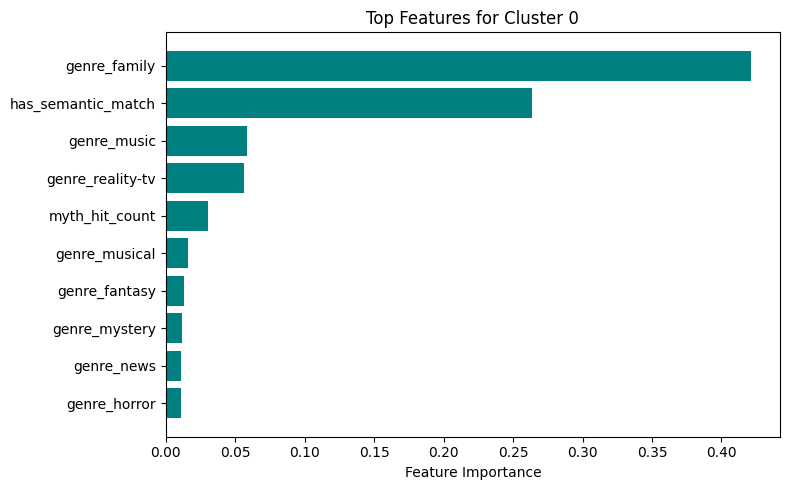

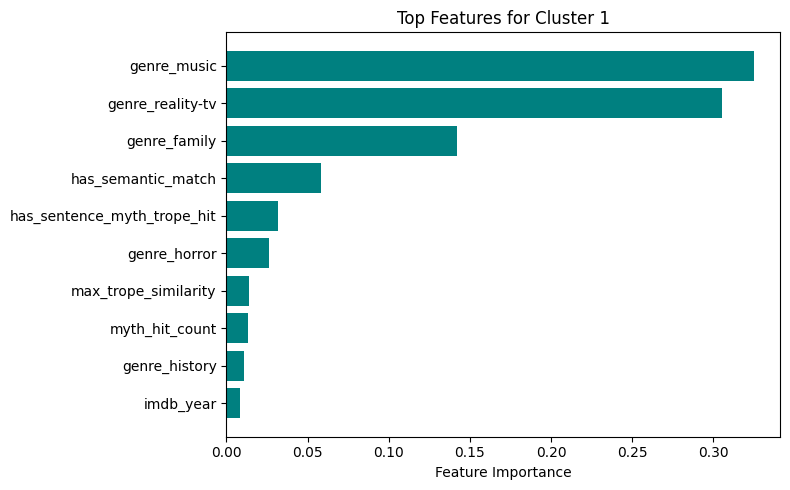

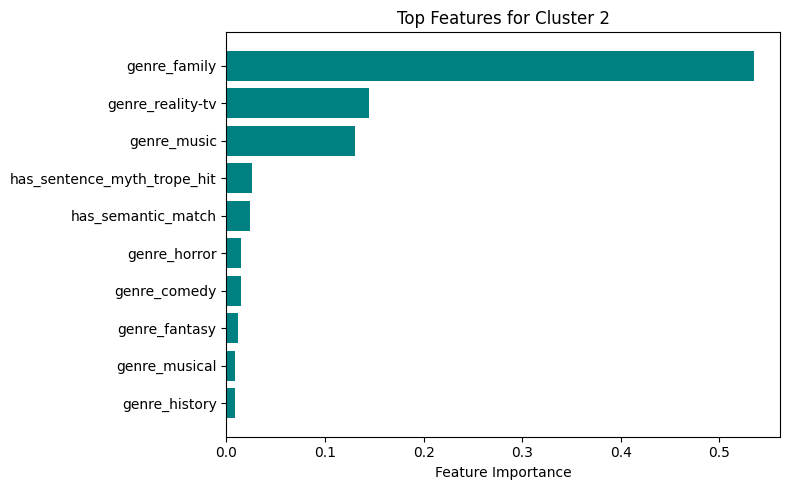

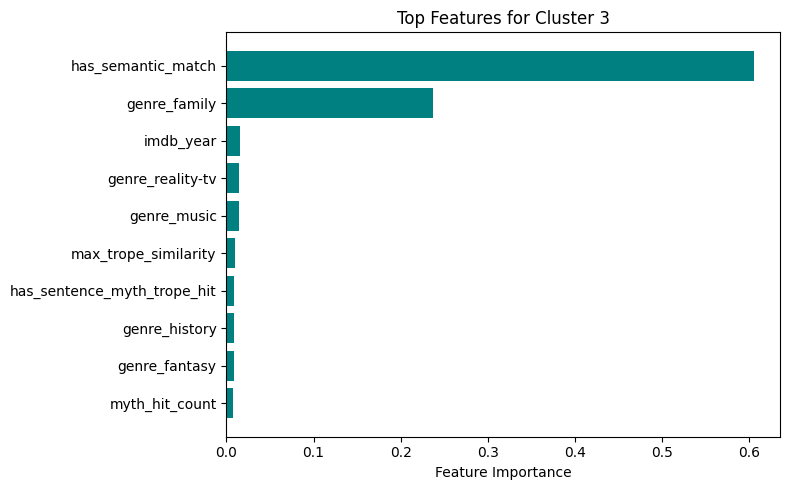

In [61]:
for idx, estimator in enumerate(ovr_rf.estimators_):
    importances = estimator.feature_importances_
    top_indices = np.argsort(importances)[::-1][:10]
    
    top_features = [feature_names[i] for i in top_indices]
    top_importances = importances[top_indices]
    
    plt.figure(figsize=(8, 5))
    plt.barh(top_features[::-1], top_importances[::-1], color='teal')
    plt.xlabel("Feature Importance")
    plt.title(f"Top Features for Cluster {idx}")
    plt.tight_layout()
    plt.show()

In [62]:
X_encoded = X_encoded.drop(columns=[col for col in X_encoded.columns if col.startswith('source_')])

In [63]:
scores = cross_val_score(ovr_rf, X_encoded, y, cv=cv, scoring='f1_macro')
print(f"Cross-validated Macro F1 Score: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Cross-validated Macro F1 Score: 0.6710 ± 0.0187


In [64]:
feature_names = X_encoded.columns

for idx, estimator in enumerate(ovr_rf.estimators_):
    importances = estimator.feature_importances_
    top_indices = np.argsort(importances)[::-1][:10]
    
    print(f"\nTop features for Cluster {idx}:")
    for i in top_indices:
        print(f"{feature_names[i]}: {importances[i]:.4f}")


Top features for Cluster 0:
genre_family: 0.4211
has_semantic_match: 0.2633
genre_music: 0.0582
genre_reality-tv: 0.0561
myth_hit_count: 0.0302
genre_musical: 0.0164
genre_fantasy: 0.0131
genre_mystery: 0.0120
genre_news: 0.0111
genre_horror: 0.0109

Top features for Cluster 1:
genre_music: 0.3249
genre_reality-tv: 0.3051
genre_family: 0.1423
has_semantic_match: 0.0582
has_sentence_myth_trope_hit: 0.0319
genre_horror: 0.0262
max_trope_similarity: 0.0140
myth_hit_count: 0.0130
genre_history: 0.0109
imdb_year: 0.0083

Top features for Cluster 2:
genre_family: 0.5347
genre_reality-tv: 0.1445
genre_music: 0.1305
has_sentence_myth_trope_hit: 0.0261
has_semantic_match: 0.0242
genre_horror: 0.0149
genre_comedy: 0.0145
genre_fantasy: 0.0116
genre_musical: 0.0085
genre_history: 0.0082

Top features for Cluster 3:
has_semantic_match: 0.6052
genre_family: 0.2371
imdb_year: 0.0155
genre_reality-tv: 0.0144
genre_music: 0.0143
max_trope_similarity: 0.0103
has_sentence_myth_trope_hit: 0.0090
genre_h

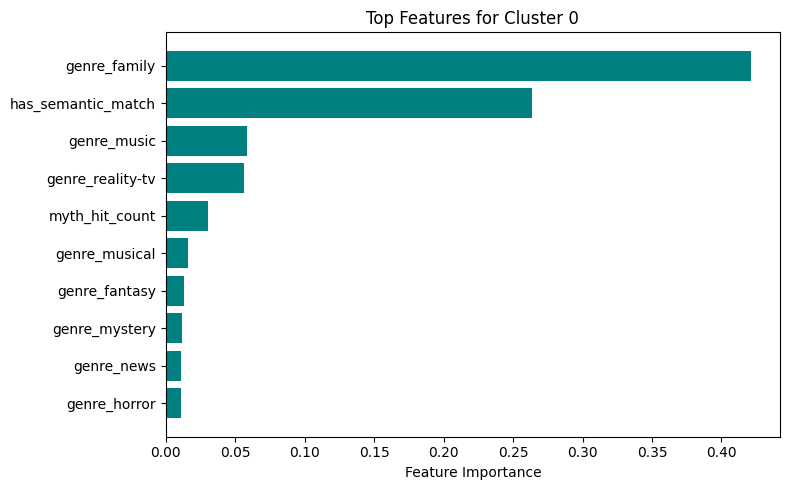

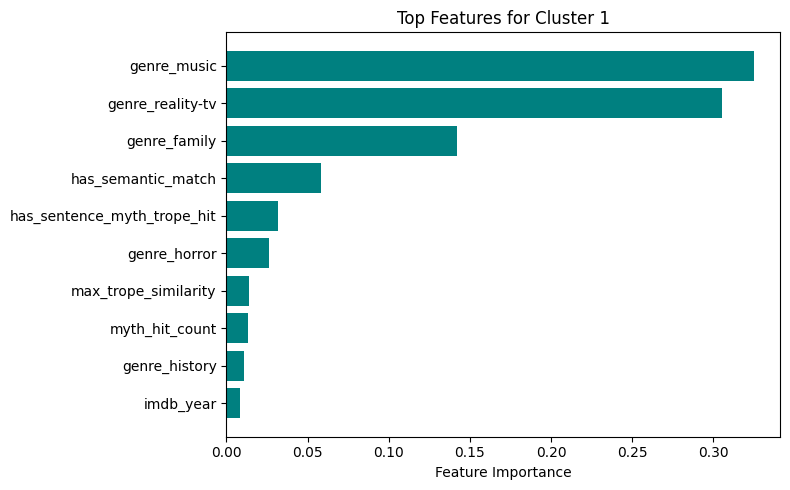

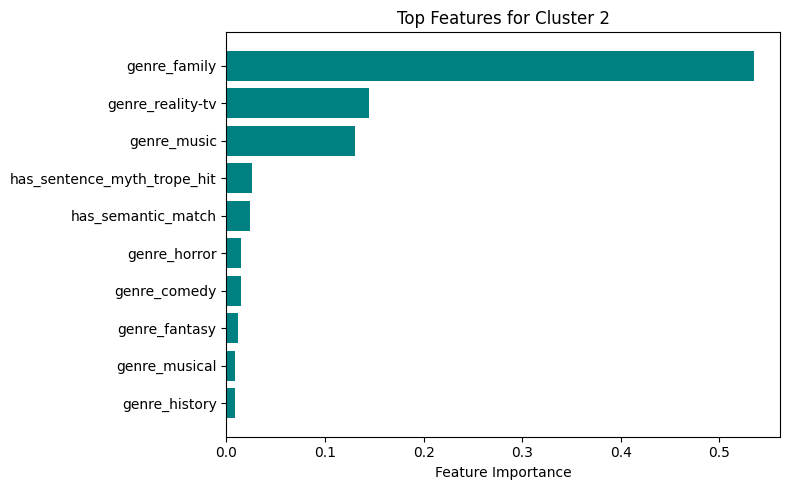

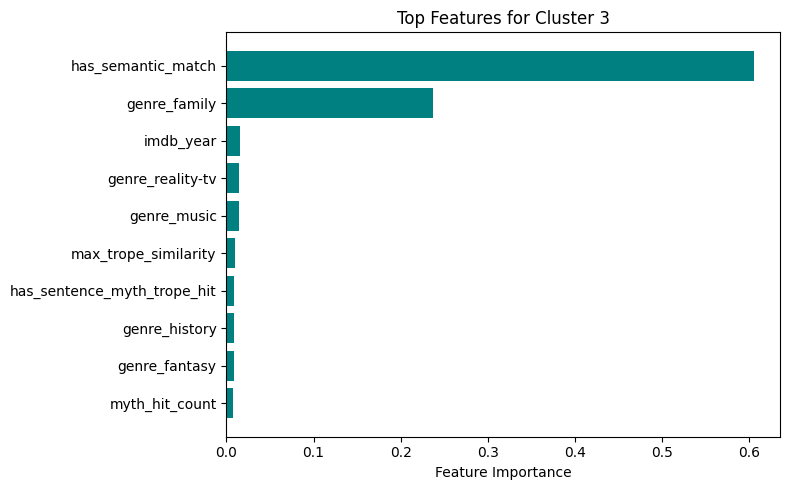

In [67]:
for idx, estimator in enumerate(ovr_rf.estimators_):
    importances = estimator.feature_importances_
    top_indices = np.argsort(importances)[::-1][:10]
    
    top_features = [feature_names[i] for i in top_indices]
    top_importances = importances[top_indices]
    
    plt.figure(figsize=(8, 5))
    plt.barh(top_features[::-1], top_importances[::-1], color='teal')
    plt.xlabel("Feature Importance")
    plt.title(f"Top Features for Cluster {idx}")
    plt.tight_layout()
    plt.show()